# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [89]:
# loading relevant packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [90]:
df = pd.read_csv('data/cleaned_aviation_data.csv', parse_dates=['Event.Date'])

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [91]:
THRESHOLD = 20

small = df[df['Total.Passengers'] <= THRESHOLD].copy()
large = df[df['Total.Passengers'] > THRESHOLD].copy()

print(f'Small aircraft accidents (<=20 passengers): {len(small):,}')
print(f'Large aircraft accidents ( >20 passengers): {len(large):,}')
print()
print('Small - unique Makes:', small['Make'].nunique())
print('Large - unique Makes:', large['Make'].nunique())


Small aircraft accidents (<=20 passengers): 17,006
Large aircraft accidents ( >20 passengers): 873

Small - unique Makes: 36
Large - unique Makes: 12


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

Top 15 small makes - lowest mean injury rate:
Make
BOMBARDIER INC                    0.091
MCDONNELL DOUGLAS                 0.094
BOMBARDIER                        0.104
BOEING                            0.142
AVIAT AIRCRAFT INC                0.164
MAULE                             0.165
GRUMMAN ACFT ENG COR-SCHWEIZER    0.207
AYRES                             0.216
STINSON                           0.216
AVIAT                             0.221
BELLANCA                          0.223
DIAMOND AIRCRAFT IND INC          0.223
ROCKWELL INTERNATIONAL            0.224
AERONCA                           0.226
DEHAVILLAND                       0.229
Name: Injury.Rate, dtype: float64

Top 15 large makes - lowest mean injury rate:
Make
DEHAVILLAND          0.000
CESSNA               0.000
PIPER                0.000
GRUMMAN              0.000
MCDONNELL DOUGLAS    0.008
BOMBARDIER INC       0.029
BOEING               0.057
BOMBARDIER           0.064
EMBRAER              0.065
AIRBUS              

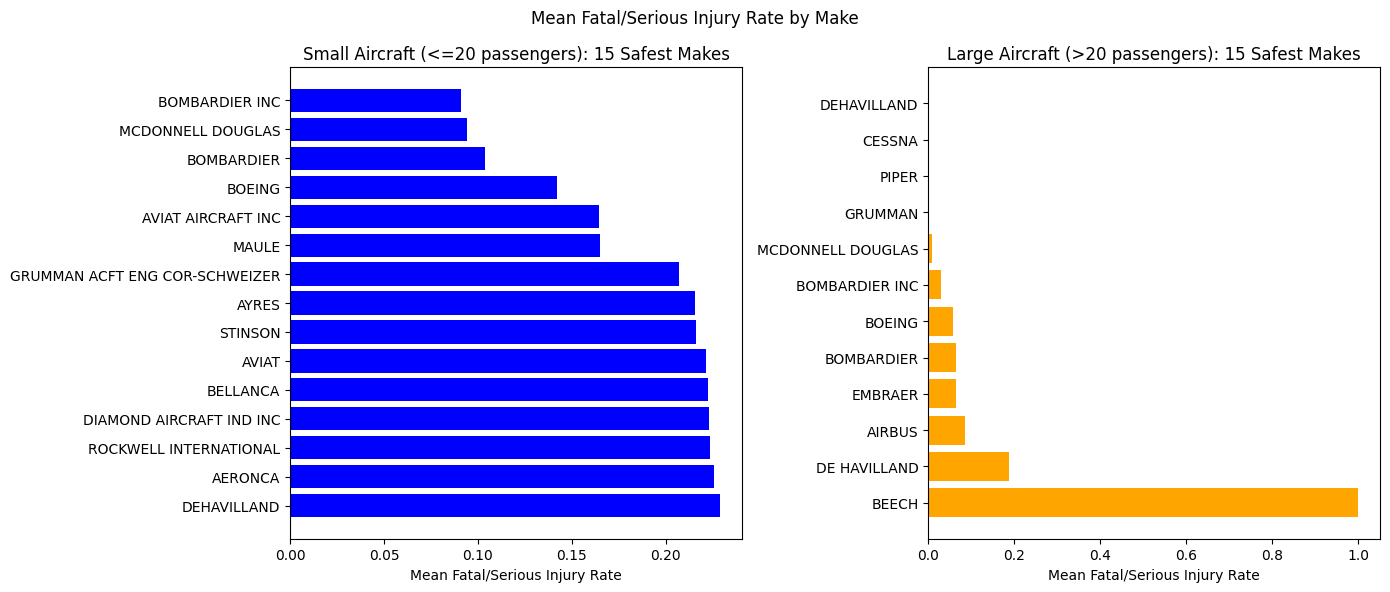

In [92]:
N_MAKES = 15

small_make_rate = (
    small.groupby('Make')['Injury.Rate']
    .mean()
    .sort_values()
    .head(N_MAKES)
)

large_make_rate = (
    large.groupby('Make')['Injury.Rate']
    .mean()
    .sort_values()
    .head(N_MAKES)
)

print('Top 15 small makes - lowest mean injury rate:')
print(small_make_rate.round(3))
print()
print('Top 15 large makes - lowest mean injury rate:')
print(large_make_rate.round(3))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(small_make_rate.index, small_make_rate.values, color='blue')
axes[0].set_xlabel('Mean Fatal/Serious Injury Rate')
axes[0].set_title('Small Aircraft (<=20 passengers): 15 Safest Makes')
axes[0].invert_yaxis()

axes[1].barh(large_make_rate.index, large_make_rate.values, color='orange')
axes[1].set_xlabel('Mean Fatal/Serious Injury Rate')
axes[1].set_title('Large Aircraft (>20 passengers): 15 Safest Makes')
axes[1].invert_yaxis()

plt.suptitle('Mean Fatal/Serious Injury Rate by Make')
plt.tight_layout()
plt.show()


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\Rama Irama\AppData\Local\Temp\ipykernel_6632\3185787046.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


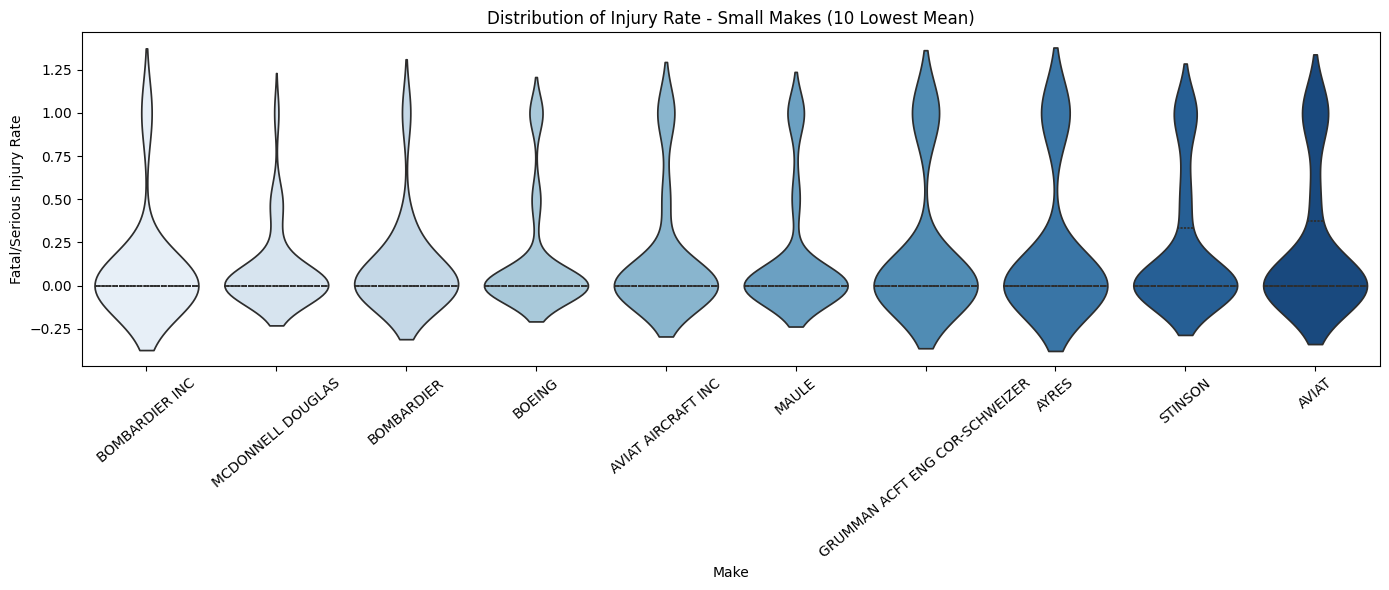

In [93]:
top10_small_makes = (
    small.groupby('Make')['Injury.Rate']
    .mean()
    .sort_values()
    .head(10)
    .index
)

small_top10 = small[small['Make'].isin(top10_small_makes)].copy()
small_top10['Make'] = pd.Categorical(
    small_top10['Make'], categories=top10_small_makes, ordered=True
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(
    data=small_top10,
    x='Make', y='Injury.Rate',
    order=top10_small_makes,
    palette='Blues', inner='quartile', ax=ax
)
ax.set_title('Distribution of Injury Rate - Small Makes (10 Lowest Mean)')
ax.set_xlabel('Make')
ax.set_ylabel('Fatal/Serious Injury Rate')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()


**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\Rama Irama\AppData\Local\Temp\ipykernel_6632\1682205193.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


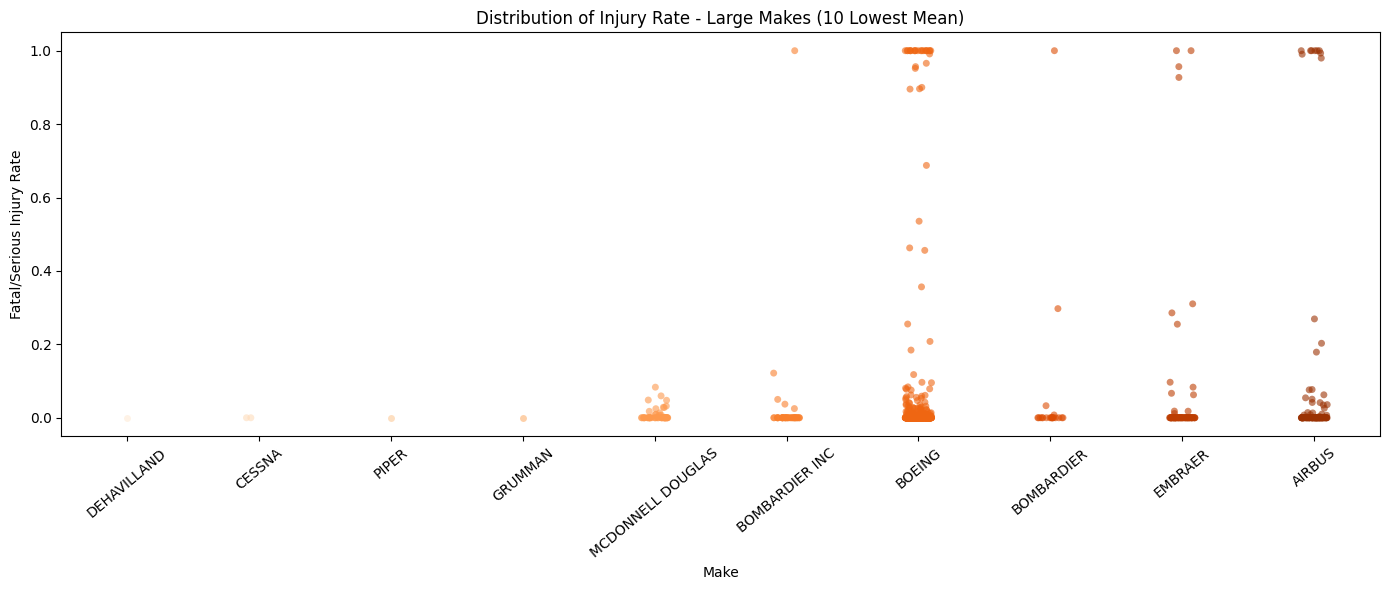

In [94]:
top10_large_makes = (
    large.groupby('Make')['Injury.Rate']
    .mean()
    .sort_values()
    .head(10)
    .index
)

large_top10 = large[large['Make'].isin(top10_large_makes)].copy()
large_top10['Make'] = pd.Categorical(
    large_top10['Make'], categories=top10_large_makes, ordered=True
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(
    data=large_top10,
    x='Make', y='Injury.Rate',
    order=top10_large_makes,
    palette='Oranges', jitter=True, alpha=0.6, size=5, ax=ax
)
ax.set_title('Distribution of Injury Rate - Large Makes (10 Lowest Mean)')
ax.set_xlabel('Make')
ax.set_ylabel('Fatal/Serious Injury Rate')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()


**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

15 small makes with lowest destruction rate:
Make
LUSCOMBE                          0.014
GRUMMAN ACFT ENG COR-SCHWEIZER    0.017
STINSON                           0.023
TAYLORCRAFT                       0.032
AERONCA                           0.035
ERCOUPE                           0.038
AMERICAN CHAMPION AIRCRAFT        0.039
AVIAT AIRCRAFT INC                0.040
MAULE                             0.042
DEHAVILLAND                       0.044
BELLANCA                          0.050
DIAMOND AIRCRAFT IND INC          0.054
BOMBARDIER                        0.056
BOEING                            0.067
CHAMPION                          0.076

15 large makes with lowest destruction rate:
Make
DEHAVILLAND          0.000
BOMBARDIER INC       0.038
BOMBARDIER           0.056
EMBRAER              0.089
BOEING               0.097
MCDONNELL DOUGLAS    0.111
DE HAVILLAND         0.167
AIRBUS               0.170
BEECH                1.000
CESSNA                 NaN
GRUMMAN                NaN
PI

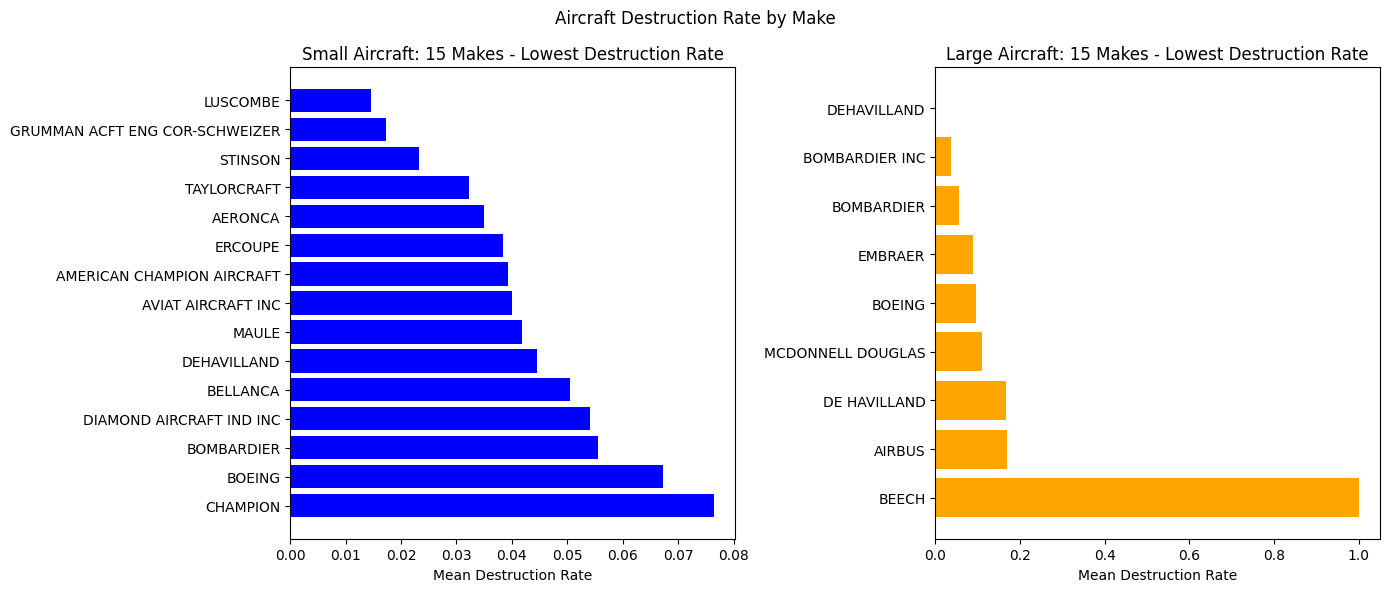

In [95]:
N = 15

small_dest = (
    small.groupby('Make')['Aircraft.Destroyed']
    .mean()
    .sort_values()
    .head(N)
)

large_dest = (
    large.groupby('Make')['Aircraft.Destroyed']
    .mean()
    .sort_values()
    .head(N)
)

print('15 small makes with lowest destruction rate:')
print(small_dest.round(3).to_string())
print()
print('15 large makes with lowest destruction rate:')
print(large_dest.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(small_dest.index, small_dest.values, color='blue')
axes[0].set_xlabel('Mean Destruction Rate')
axes[0].set_title('Small Aircraft: 15 Makes - Lowest Destruction Rate')
axes[0].invert_yaxis()

axes[1].barh(large_dest.index, large_dest.values, color='orange')
axes[1].set_xlabel('Mean Destruction Rate')
axes[1].set_title('Large Aircraft: 15 Makes - Lowest Destruction Rate')
axes[1].invert_yaxis()

plt.suptitle('Aircraft Destruction Rate by Make')
plt.tight_layout()
plt.show()


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Small makes tend to have lower destruction rates than Large makes. For small makes, I'd recommend LUSCOMBE, GRUMAN, and STINSON. For Large makes, I'd recommend DEHAVILLAND, BOMBARDIER, and EMBRAER.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Large models with >= 10 records: 14
Make.Model
BOEING 777                    0.001
BOEING 757                    0.001
BOEING 787                    0.003
BOEING 737-7H4                0.003
BOMBARDIER INC CL-600-2B19    0.004
EMBRAER EMB145                0.009
EMBRAER EMB-145LR             0.010
BOEING 747                    0.023
BOEING 767                    0.047
BOEING 737 7H4                0.068
BOEING 737                    0.081
AIRBUS A320                   0.127
AIRBUS A330                   0.147
AIRBUS A321                   0.200


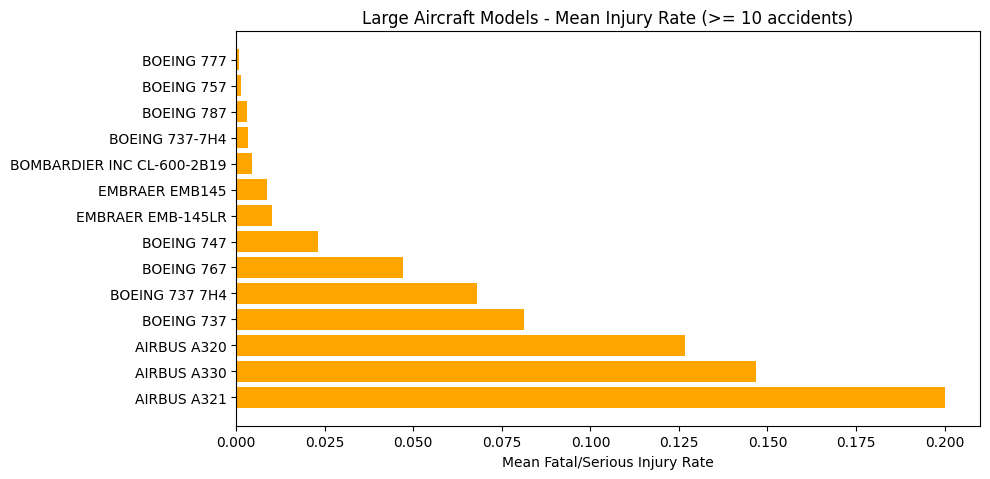

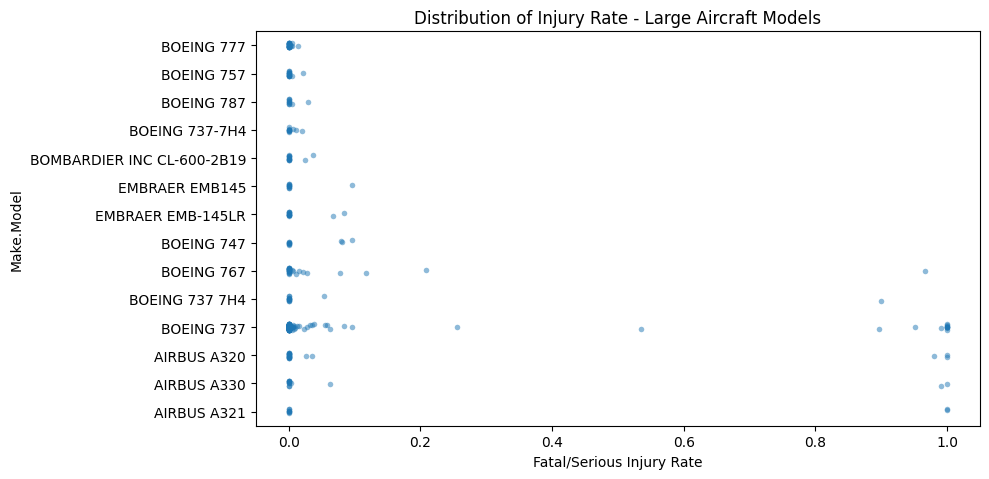

In [96]:
MIN_COUNT = 10

large_model_counts = large.groupby('Make.Model')['Injury.Rate'].count()
valid_large_models = large_model_counts[large_model_counts >= MIN_COUNT].index
large_filtered = large[large['Make.Model'].isin(valid_large_models)]

large_model_rate = (
    large_filtered.groupby('Make.Model')['Injury.Rate']
    .mean()
    .sort_values()
)

print(f'Large models with >= {MIN_COUNT} records: {len(large_model_rate)}')
print(large_model_rate.round(3).to_string())

n_rows = max(5, len(large_model_rate))
fig, ax = plt.subplots(figsize=(10, n_rows * 0.35))
ax.barh(large_model_rate.index, large_model_rate.values, color='orange')
ax.set_xlabel('Mean Fatal/Serious Injury Rate')
ax.set_title(f'Large Aircraft Models - Mean Injury Rate (>= {MIN_COUNT} accidents)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, n_rows * 0.35))
sns.stripplot(
    data=large_filtered[large_filtered['Make.Model'].isin(large_model_rate.index)],
    y='Make.Model', x='Injury.Rate',
    order=large_model_rate.index,
    jitter=True, alpha=0.5, size=4, ax=ax
)
ax.set_title('Distribution of Injury Rate - Large Aircraft Models')
ax.set_xlabel('Fatal/Serious Injury Rate')
ax.set_ylabel('Make.Model')
plt.tight_layout()
plt.show()


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Small models with >= 10 records: 339
Top 10 by lowest mean injury rate:
Make.Model
CESSNA 172SP                         0.000
MAULE M-5-210C                       0.000
DIAMOND AIRCRAFT IND INC DA 20 C1    0.000
CESSNA 180J                          0.036
CESSNA A185E                         0.039
PIPER PA-20                          0.040
BEECH B19                            0.042
AIR TRACTOR AT 602                   0.042
CESSNA 560XL                         0.048
CESSNA 180H                          0.049


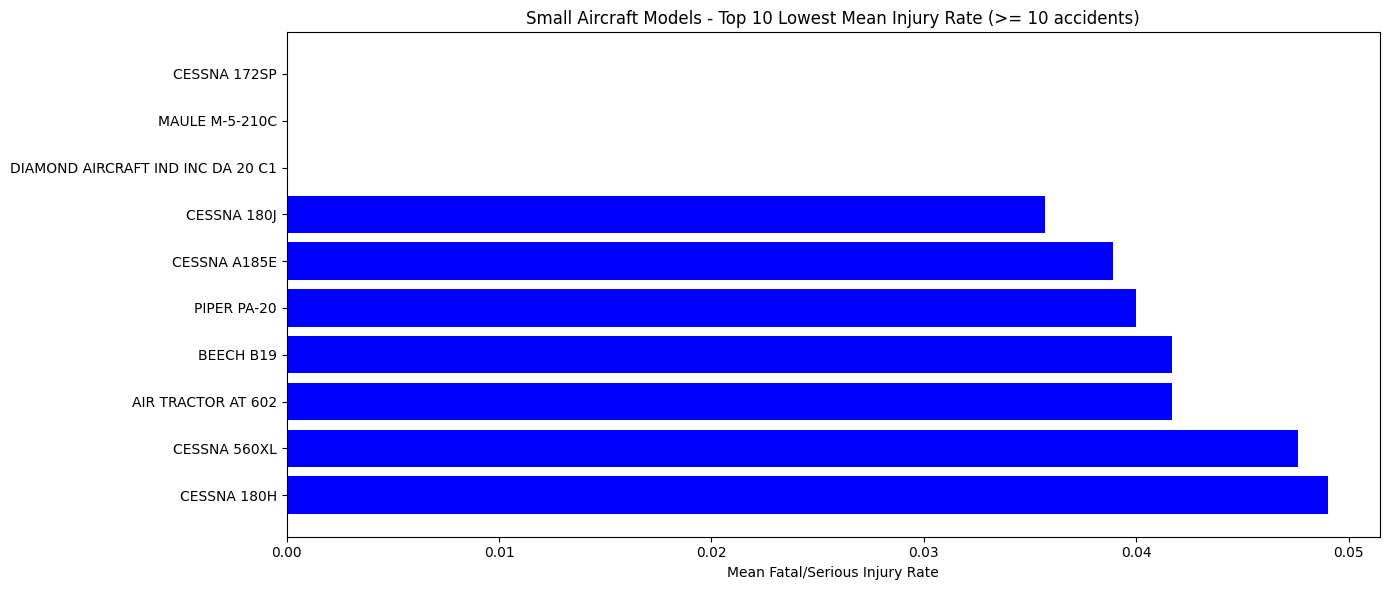

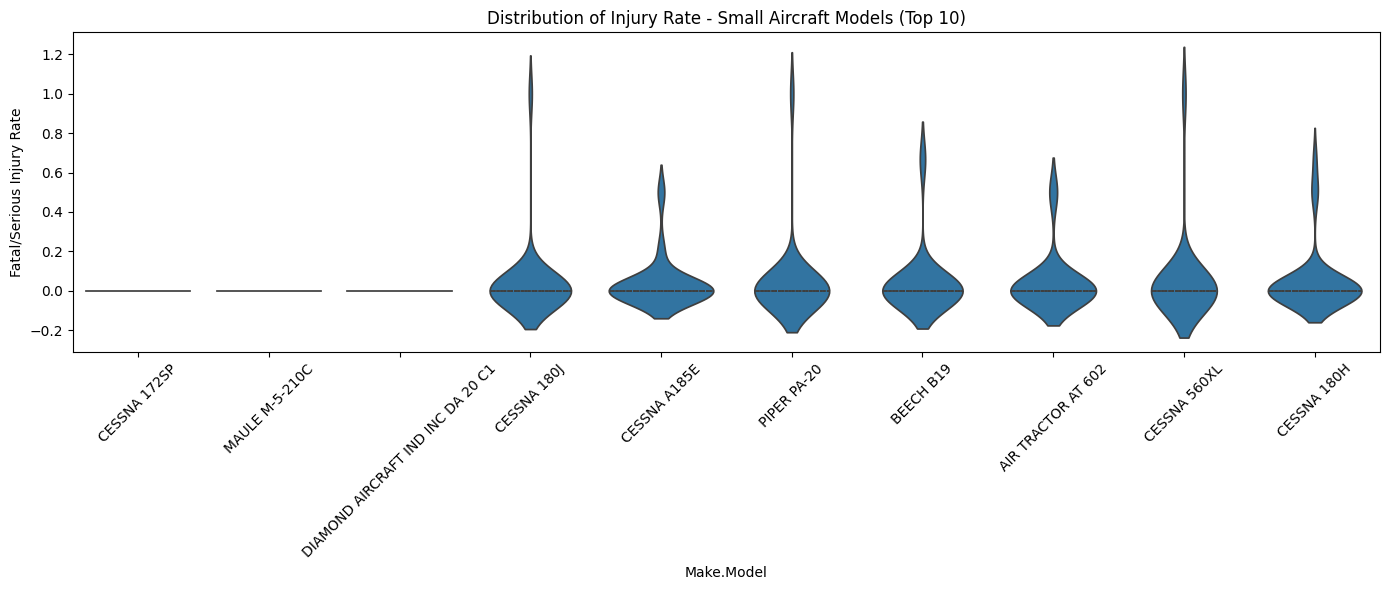

In [ ]:
small_model_counts = small.groupby('Make.Model')['Injury.Rate'].count()
valid_small_models = small_model_counts[small_model_counts >= MIN_COUNT].index
small_filtered = small[small['Make.Model'].isin(valid_small_models)]

small_model_rate = (
    small_filtered.groupby('Make.Model')['Injury.Rate']
    .mean()
    .sort_values()
    .head(10)
)

n_valid_small = small_model_counts[small_model_counts >= MIN_COUNT].shape[0]
print(f'Small models with >= {MIN_COUNT} records: {n_valid_small}')
print('Top 10 by lowest mean injury rate:')
print(small_model_rate.round(3).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(small_model_rate.index, small_model_rate.values, color='blue')
ax.set_xlabel('Mean Fatal/Serious Injury Rate')
ax.set_title(f'Small Aircraft Models - Top 10 Lowest Mean Injury Rate (>= {MIN_COUNT} accidents)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

small_top10_models = small_filtered[small_filtered['Make.Model'].isin(small_model_rate.index)].copy()
small_top10_models['Make.Model'] = pd.Categorical(
    small_top10_models['Make.Model'], categories=small_model_rate.index, ordered=True
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(
    data=small_top10_models,
    x='Make.Model', y='Injury.Rate',
    order=small_model_rate.index,
    inner='quartile', ax=ax
)
ax.set_title('Distribution of Injury Rate - Small Aircraft Models (Top 10)')
ax.set_xlabel('Make.Model')
ax.set_ylabel('Fatal/Serious Injury Rate')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Regarding Mean Injury Rate, Large models with the lowest rates are BOEING 777, BOEING 757, and BOEING 787. Smaller models with the lowest rates are CESSNA 1752P, MAULE M-5-210C. and DIAMOND AIRCRAFT IND INC DA 20 C1.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Weather Condition Summary:


,count,mean_injury_rate,mean_destroyed
Weather.Condition,,,
IMC,895,0.628,0.368
VMC,14248,0.233,0.072


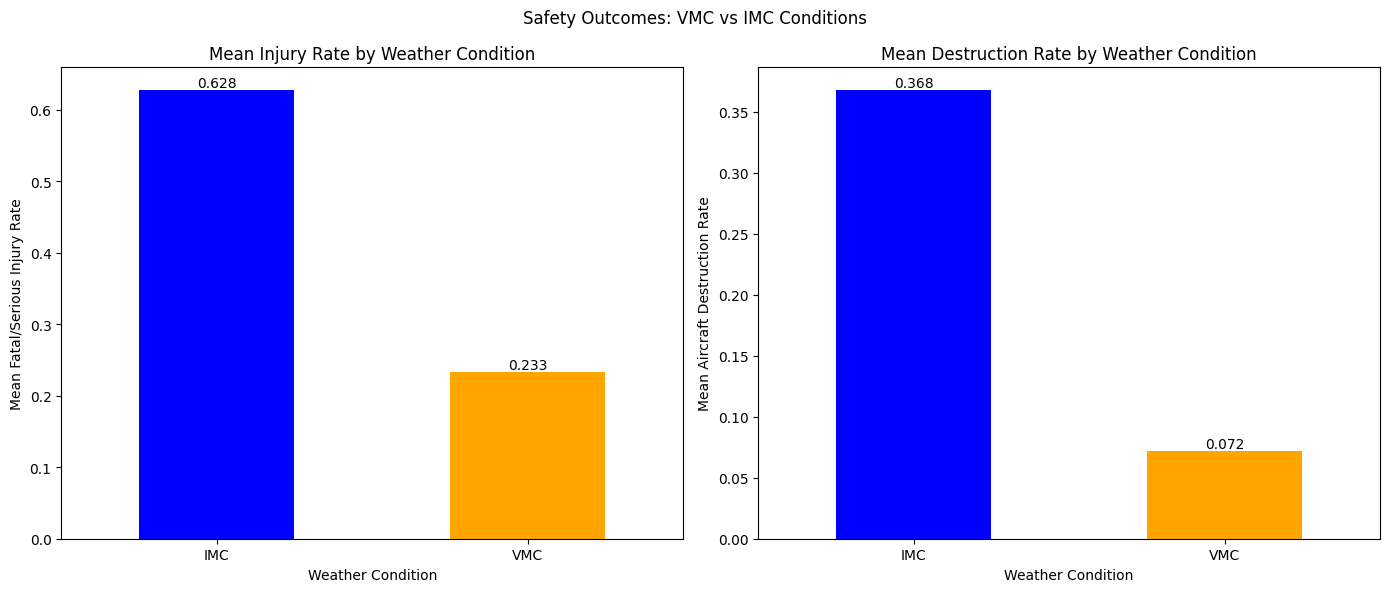

Number of Engines Summary:


,count,mean_injury_rate,median_injury_rate,std_injury_rate,mean_destroyed
Engines,,,,,
1 Engine,13184,0.256,0.0,0.415,0.078
2 Engines,2282,0.276,0.0,0.430,0.167


C:\Users\Rama Irama\AppData\Local\Temp\ipykernel_6632\1437667711.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


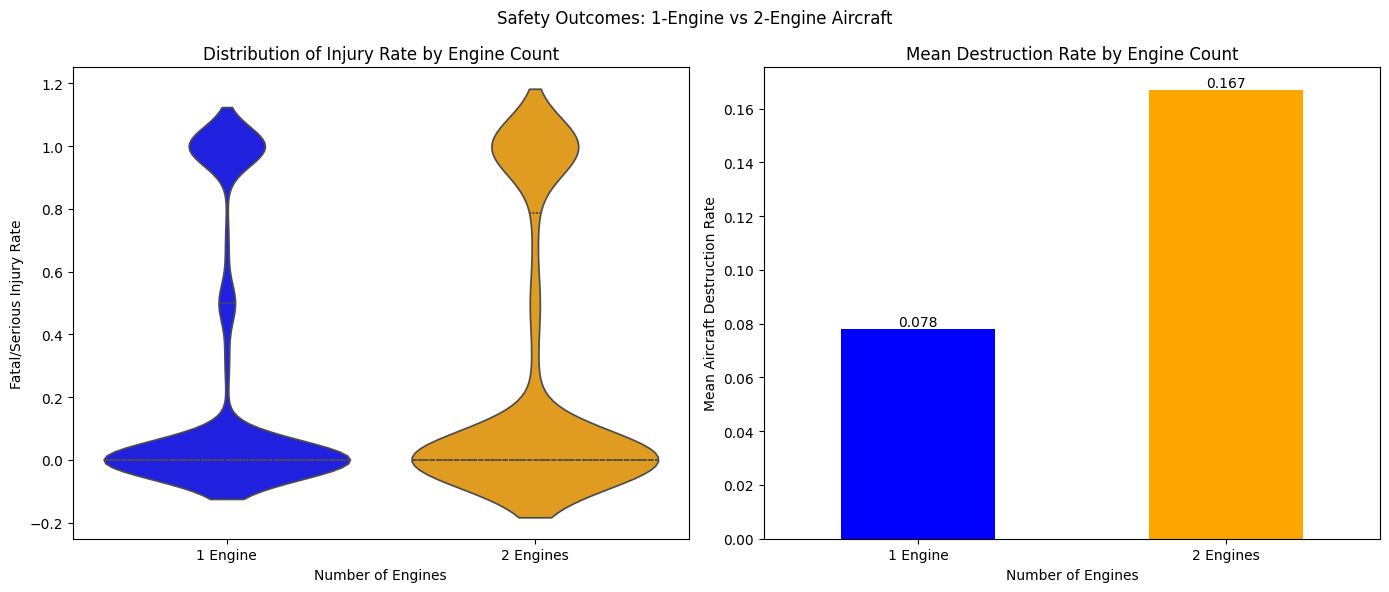

In [98]:
weather_valid = df[df['Weather.Condition'].isin(['VMC', 'IMC'])].copy()

weather_stats = weather_valid.groupby('Weather.Condition').agg(
    count=('Injury.Rate', 'count'),
    mean_injury_rate=('Injury.Rate', 'mean'),
    mean_destroyed=('Aircraft.Destroyed', 'mean')
).round(3)

print('Weather Condition Summary:')
display(weather_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['blue', 'orange']

weather_stats['mean_injury_rate'].plot.bar(ax=axes[0], color=colors, rot=0)
axes[0].set_title('Mean Injury Rate by Weather Condition')
axes[0].set_ylabel('Mean Fatal/Serious Injury Rate')
axes[0].set_xlabel('Weather Condition')
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():.3f}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom')

weather_stats['mean_destroyed'].plot.bar(ax=axes[1], color=colors, rot=0)
axes[1].set_title('Mean Destruction Rate by Weather Condition')
axes[1].set_ylabel('Mean Aircraft Destruction Rate')
axes[1].set_xlabel('Weather Condition')
for bar in axes[1].patches:
    axes[1].annotate(f'{bar.get_height():.3f}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom')

plt.suptitle('Safety Outcomes: VMC vs IMC Conditions')
plt.tight_layout()
plt.show()



engines_valid = df[df['Number.of.Engines'].isin([1.0, 2.0])].copy()
engines_valid['Engines'] = engines_valid['Number.of.Engines'].map(
    {1.0: '1 Engine', 2.0: '2 Engines'}
)

engine_stats = engines_valid.groupby('Engines').agg(
    count=('Injury.Rate', 'count'),
    mean_injury_rate=('Injury.Rate', 'mean'),
    median_injury_rate=('Injury.Rate', 'median'),
    std_injury_rate=('Injury.Rate', 'std'),
    mean_destroyed=('Aircraft.Destroyed', 'mean')
).round(3)

print('Number of Engines Summary:')
display(engine_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(
    data=engines_valid,
    x='Engines', y='Injury.Rate',
    palette=['blue', 'orange'],
    inner='quartile', ax=axes[0]
)
axes[0].set_title('Distribution of Injury Rate by Engine Count')
axes[0].set_ylabel('Fatal/Serious Injury Rate')
axes[0].set_xlabel('Number of Engines')

engine_stats['mean_destroyed'].plot.bar(
    ax=axes[1], color=['blue', 'orange'], rot=0
)
axes[1].set_title('Mean Destruction Rate by Engine Count')
axes[1].set_ylabel('Mean Aircraft Destruction Rate')
axes[1].set_xlabel('Number of Engines')
for bar in axes[1].patches:
    axes[1].annotate(f'{bar.get_height():.3f}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom')

plt.suptitle('Safety Outcomes: 1-Engine vs 2-Engine Aircraft')
plt.tight_layout()
plt.show()


**Weather Conditions Discussion** 
Regarding mean injury rate, IMC accidents have a rate of 0.628 while VMC accidents have a rate of 0.233.
Regarding mean destruction rate, IMC accidents have a rate of 0.368 while VMC accidents have a rate of 0.72

**Number of Engines Discussion**
Regarding the injury rate distribution, 1-Engine aircrafts have a higher standard distribution that 2-Engine aircrafts.
Regarding the mean destruction rate, 1-engine aircrafts have a mean destruction rate of 0.078 while 2-engine aircrafts have a mean destruction rate of 0.167.